# ¡Bienvenidos a la segunda clase de la Quantum Jam 2025!

<img src= "https://raw.githubusercontent.com/santiago-feldman/Quantum-Computing-and-Qiskit-v2.X-notebooks/main/images/Fall%20Fest%20Graphics/Illustration%20Exports/Full_Illustration.png" />

Hola! Esperamos que puedan haber aprendido sobre los fundamentos de la computación cuántica en la Clase 1, junto con algunas clases y métodos de *Qiskit*.

Aprender los principios básicos puede ser difícil y demasiado matemático para muchas personas. En esta clase, vamos a crear circuitos cuánticos y obtener los kets de estado a partir de ellos. Van a ver que trabajar con compuertas y circuitos es mucho más fácil (y divertido) que trabajar con vectores de estado y operadores directamente. En las Clases 3 y 4, utilizaremos estos circuitos para desarrollar algoritmos y protocolos de comunicación.

**Guardar esta clase:** para guardar las clase y el código que escriban en los ejercicios, les recomendamos hacer una copia de este doumento en su carpeta de Google Drive. Seleccionen ```Archivo```, arriba a la izquierda en Google Collab, y luego elijan la opción ```Guardar una copia en Drive```.

**Instalación:** para instalar todas las librerías y servicios necesarios para esta clase, corran la siguiente celda apretando el botón de play a la izquierda.

In [ ]:
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer qiskit_qasm3_import

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_bloch_vector
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter, ParameterVector
import qiskit.qasm3
from qiskit_ibm_runtime.fake_provider import FakeVigoV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, EstimatorV2 as Estimator, QiskitRuntimeService

# Compuertas y circuitos cuánticos

## Compuertas lógicas

A grandes rasgos, las computadoras clásicas están hechas con cables, que transportan señales eléctricas, y **compuertas lógicas**, que manipulan la información de dichas señales.

La única compuerta lógica de un bit que no es trivial es la compuerta NOT, que invierte el valor del bit: si el *input* es $0$, el *output* será $1$ y viceversa. Su símbolo y *tabla de verdad* se muestran a continuación:

<img src="https://graphicmaths.com/img/computer-science/logic/logic-gates/not-gate.png" width="400" />

Algunas compuertas de dos entradas (es decir, de dos bits) son las compuertas AND, NAND, OR, NOR, XOR y XNOR. Las compuertas NAND, NOR y XNOR son las compuertas AND, OR y XOR respectivamente, seguidas de una NOT conectada en serie. Pueden ver sus símbolos y tablas de verdad [acá](https://es.wikipedia.org/wiki/Puerta_l%C3%B3gica#Conjunto_de_compuertas_l%C3%B3gicas_completo).

Existe una cantidad finita de compuertas lógicas no triviales. Cualquiera de ellas puede sintetizarse a partir de la combinación de compuertas NAND, conocida como la compuerta *universal*.

Muchas de las compuertas lógicas son *irreversibles* (o *no-reversibles*). Por ejemplo, dado el resultado de una compuerta NAND o una XOR, es imposible determinar cuáles fueron los estados de entrada $X$ e $Y$. Hay una pérdida irreparable de información asociada a la aplicación de una compuerta clásica.

**Nota:** las compuertas lógicas son una pieza clave de los circuitos digitales. Existen otros dispositivos electrónicos digitales - como multiplexores, decodificadores, codificadores, sumadores y restadores - que son importantes para sintetizar *circuitos combinacionales*: circuitos lógicos digitales que solo dependen de las entradas ("no tienen memoria"). Existen otros tipos de circuitos digitales llamados *circuitos secuenciales*, que además dependen de estados pasados; es decir, requieren memoria y realimentación. Estos circuitos utilizan flip-flops, clocks (relojes) y contadores, entre otros dispositivos electrónicos. No nos adentraremos específicamente en temas de electrónica digital, pero los interesados pueden consultar la bibliografía sugerida.

## Compuertas cuánticas de un solo qubit

Así como en las computadoras clásicas contamos con compuertas lógicas, en las computadoras cuánticas utilizamos **compuertas cuánticas**, que cambiarán el estado de los qubits de nuestros circuitos cuánticos. Una compuerta cuántica $U$ que actúa sobre un solo qubit puede describirse como una matriz de $2\times2$:

\begin{equation}
U=\begin{bmatrix}a & b\\ c & d\end{bmatrix}
\end{equation}

Si tomamos la notación vectorial del qubit $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$, la compuerta se aplica de la siguiente manera:

\begin{equation}
U|\psi\rangle=\begin{bmatrix}a & b\\ c & d\end{bmatrix}\begin{bmatrix}\alpha\\\beta\end{bmatrix}=\begin{bmatrix}a\alpha+b\beta\\c\alpha+d\beta\end{bmatrix}
\end{equation}

Podemos ver que las compuertas cuánticas son **lineales**: $U|\psi\rangle=U(\alpha|0\rangle+\beta|1\rangle)=\alpha\, U|0\rangle+\beta\,U|1\rangle$ (un comportamiento no lineal nos llevaría a paradojas como viajes en el tiempo, comunicación a velocidades más rápidas que la de la luz y violaciones del segundo principio de la termodinámica). Por lo tanto, se aplicarán a todos los estados de la superposición sin que esta colapse. Esta idea nos da una noción de la mayor capacidad de procesamiento que nos permiten las compuertas cuánticas, ya que podemos evaluar muchos estados con una sola entrada.

Si la matriz que representa a la compuerta cuántica está expresada en términos de la base computacional, entonces la primera columna será el estado en el que $|0\rangle$ se transforma y la segunda columna, el estado en el que $|1\rangle$ se transforma:

\begin{equation}
U|0\rangle=\begin{bmatrix}a & b\\ c & d\end{bmatrix}\begin{bmatrix}1\\0\end{bmatrix}=\begin{bmatrix}a\\c\end{bmatrix}=a|0\rangle+c|1\rangle
\qquad
U|1\rangle=\begin{bmatrix}a & b\\ c & d\end{bmatrix}\begin{bmatrix}0\\1\end{bmatrix}=\begin{bmatrix}b\\d\end{bmatrix}=b|0\rangle+d|1\rangle
\end{equation}

El símbolo que se utiliza para expresar cualquier compuerta cuántica que actúe sobre un qubit es una "caja" o cuadrado con la letra o expresión que la representa:

<img src="https://i.imgur.com/sjrosK8.jpeg" width="500" />

Las compuertas cuánticas preservan la norma unitaria de los qubits; es decir, si un qubit $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$ atraviesa una compuerta cuántica que devuelve el estado $|\psi'\rangle=\alpha'|0\rangle+\beta'|1\rangle$, se deberá cumplir que:

\begin{equation}
|\alpha'|^2+|\beta'|^2=1
\end{equation}

Para que esta condición se cumpla, las matrices que representan a las compuertas deben ser matrices **unitarias**: $U^\dagger U=I$ (dimos un indicio de este hecho en el ejercicio 16 de la Clase 1). Por lo tanto, ¡podemos construir una compuerta cuántica a partir de cualquier operador unitario!

Por ser unitarias, el efecto de cualquier compuerta cuántica $U$ puede deshacerse aplicando otra compuerta $U^\dagger$. Por lo tanto, todas las compuertas cuánticas son **reversibles**: no hay una pérdida irreparable de información asociada a su aplicación.

A diferencia del caso clásico, existen infinitas compuertas no triviales que actúan sobre un solo qubit, ya que existen infinitas matrices unitarias de $2\times2$. Así como podemos sintetizar cualquier compuerta lógica con NANDs, podemos obtener cualquier compuerta cuántica con un conjunto finito de compuertas universales, aunque no nos adentraremos en ese tema en esta clase (quienes estén interesados, pueden consultar [1] en la bibliografía).

## Algunas compuertas famosas

En esta sección, repasaremos brevemente las compuertas más importantes que actúan sobre un solo qubit. En Qiskit, utilizaremos estas compuertas para construir nuestros circuitos y algoritmos cuánticos.

### Las compuertas de Pauli $X$, $Y$, $Z$



Tres compuertas importantes en computación cuántica son las correspondientes a las matrices de Pauli $X$, $Y$ y $Z$:

\begin{equation}
X=\begin{bmatrix}0 & 1\\ 1 & 0\end{bmatrix}
\qquad
Y=\begin{bmatrix}0 & -i\\ i & 0\end{bmatrix}
\qquad
Z=\begin{bmatrix}1 & 0\\ 0 & -1\end{bmatrix}
\end{equation}

Se puede comprobar que además de unitarias, son matrices hermíticas, por lo que son iguales a sus respectivas matrices adjuntas: aplicar dos veces cualquiera de estas compuertas devuelve el mismo estado que ingresamos.

- La compuerta $X$ (o Pauli $X$) a veces es llamada "negación", "NOT cuántica" o "bit flip", ya que intercambia los estados $|0\rangle$ y $|1\rangle$ (gira el qubit $180^\circ$ sobre el eje $x$ en la esfera de Bloch):

\begin{equation}
X|\psi\rangle=X(\alpha|0\rangle+\beta|1\rangle)=\beta|0\rangle+\alpha|1\rangle
\end{equation}

- La compuerta Pauli $Z$ también es conocida como "phase flip", ya que agrega una fase relativa de $\pi$ radianes (gira el qubit $180^\circ$ sobre el eje $z$ en la esfera de Bloch). Recuerden que $e^{i\pi}=-1$.

\begin{equation}
Z(\alpha|0\rangle+\beta|1\rangle)=\alpha|0\rangle-\beta|1\rangle
\end{equation}

- Por último, La compuerta Pauli $Y$ gira el qubit $180^\circ$ sobre el eje $y$ en la esfera de Bloch:

\begin{equation}
Y(\alpha|0\rangle+\beta|1\rangle)=i(\alpha|1\rangle-\beta|0\rangle)=i\alpha|1\rangle-i\beta|0\rangle
\end{equation}

Es fácil ver que aplicar la compuerta $Y$ es equivalente a aplicar la compuerta $Z$, luego la $X$ y finalmente agregar una fase global de $\frac{\pi}{2}$ radianes ($i=e^{i\frac{\pi}{2}}$). Por lo tanto, $Y=e^{i\frac{\pi}{2}}XZ$. Es importante tener en cuenta que la compuerta que se escribe más a la derecha es la que primero se aplica.



### Las compuertas $R(\theta)$, $S$ y $T$

Otra compuerta útil es la **compuerta de corrimiento de fase**, $R(\theta)$, que agrega una fase relativa de $\theta$ radianes al estado $|1\rangle$: $R(\theta)|0\rangle=|0\rangle$; $R(\theta)|1\rangle=e^{i\theta}|1\rangle$. Su representación matricial en la base computacional será:

\begin{equation}
R(\theta)=\begin{bmatrix}1 & 0\\ 0 & e^{i\theta}\end{bmatrix}
\end{equation}

Nótese que $R(\theta)$ genera una rotación de $\theta$ radianes sobre el eje $z$ (antihoraria si $\theta$ es positivo y horaria si es negativo). Dos casos específicos de corrimiento de fase son las compuertas $S$ y $T$, en donde $\theta=90^\circ$ y $\theta=45^\circ$ respectivamente:

\begin{equation}
S=\begin{bmatrix}1 & 0\\ 0 & i\end{bmatrix}
\qquad
T=\begin{bmatrix}1 & 0\\ 0 & e^{i\frac{\pi}{4}}\end{bmatrix}
\end{equation}

También podemos extender el concepto de la compuerta $R(\theta)$ y crear compuertas de rotaciones con un ángulo arbitrario para cada eje de la esfera de Bloch: $R_X(\theta)$, $R_Y(\theta)$ y $R_Z(\theta)$. No nos adentraremos en rotaciones más generales en esta clase, pero los que estén interesados pueden buscar más información sobre ellas en la bibliografía o en páginas como la de [este link](https://en.wikipedia.org/wiki/List_of_quantum_logic_gates).

### La compuerta de Hadamard

Una de las compuertas más importantes es la **compuerta de Hadamard**, que pone a cada estado de la base computacional en una superposición equiprobable de estados:

\begin{equation}
H|0\rangle=|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}
\qquad
H|1\rangle=|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}
\end{equation}

Por lo tanto, su representación matricial en la base computacional es:

\begin{equation}
H=\frac{1}{\sqrt{2}}\begin{bmatrix}1 & 1\\ 1 & -1\end{bmatrix}
\end{equation}

Su efecto sobre un qubit arbitrario es el siguiente:

\begin{equation}
H(\alpha|0\rangle+\beta|1\rangle)=\frac{\alpha+\beta}{\sqrt2}|0\rangle+\frac{\alpha-\beta}{\sqrt2}|1\rangle
\end{equation}

Podemos ver que las amplitudes de probabilidad originales $\alpha$ y $\beta$ se suman en el estado $|0\rangle$ y se restan en el estado $|1\rangle$. Decimos que tenemos **interferencia constructiva** o positiva para el ket $|0\rangle$ (aumenta la probabilidad de medir $0$) e **interferencia destructiva** o negativa para el ket $|1\rangle$ (disminuye la probabilidad de medir $1$). Podemos utilizar este fenómeno de **interferencia cuántica** en algoritmos cuánticos para aumentar la probabilidad de medir estados deseables.

Visualmente, la compuerta de Hadamard rota al qubit $90^\circ$ sobre el eje $y$ en la esfera de Bloch y luego realiza una reflexión sobre el plano $xy$.

---

En conclusión, vimos que mientras que en la computación clásica solo hay una compuerta no trivial que opera sobre un bit, en la computación cuántica tenemos muchas compuertas no triviales que operan sobre un qubit:

<img src="https://i.imgur.com/B5nfvGn.jpeg" width="700" />

## Circuitos cuánticos

Ya vimos cómo representar compuertas cuánticas. Ahora, agregaremos otras reglas y símbolos para dibujar circuitos cuánticos. El siguiente código implementa un circuito cuántico básico en Qiskit:

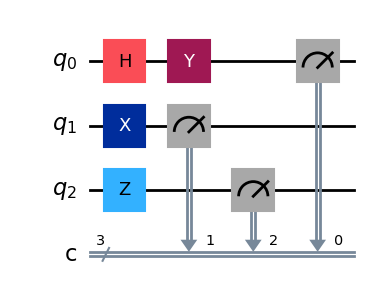

In [ ]:
qc = QuantumCircuit(3, 3)

qc.h(0)
qc.x(1)
qc.z(2)
qc.y(0)

qc.measure([0, 1, 2], [0, 1, 2])

qc.draw('mpl')


Veamos algunas reglas y convenciones básicas de los circuitos cuánticos:

- Se leen de izquierda a derecha.

- Cada línea horizontal representa un **cable** del circuito. Los de una línea (que contienen las etiquetas $q_i$) son cables cuánticos y los grises de dos líneas (referenciados por la letra $c$) son cables clásicos. A diferencia de las computadoras clásicas, los cables no son cables físicos necesariamente, sino que pueden representar el paso del tiempo, o una partícula - como un fotón - moviéndose de un lugar a otro en el espacio.

- Las entradas del circuito suelen ser $|0\rangle$ en cada cable. Si el estado de entrada es otro, se suele informar en el dibujo.

El estado del circuito cuántico en un tiempo determinado ($t$) está dado por un ket $|\psi(t)\rangle$ que contiene información sobre el estado de todos los qubits del circuito en ese momento; por ejemplo: $|\psi(t)\rangle=|q_0(t)\rangle|q_1(t)\rangle|q_2(t)\rangle$.

En el código anterior, utilizamos la librería ```matplotlib``` para dibujar el circuito. Se pueden ver las compuertas $H$, $X$, $Y$ y $Z$ representadas con diferentes colores. Los otros "cuadrados" del dibujo representan la acción de medir u observar un qubit: son mediciones proyectivas cuyo resultado se muestra en cables clásicos (el cable de más abajo en el dibujo; el símbolo $/$ con el número 3 significa que tenemos tres cables clásicos).



A continuación, se muestran algunos símbolos comunes de los circuitos cuánticos. La imagen fue extraída del libro "Quantum Computation and Quantum Information", de Michael A. Nielsen e Isaac L. Chuang.

<img src="https://i.imgur.com/ObWJGh1.jpeg" />


**Nota:** existen algunas operaciones de los circuitos clásicos que **no** podemos realizar con circuitos cuánticos:

1. “Loops” o realimentación (*feedback*). Los circuitos cuánticos son *acíclicos*.
2. *FANIN*: ”unir” los cables en uno solo que contenga un *OR bitwise* de las entradas. Dicha operación no es reversible y por lo tanto no es unitaria.
3. *FANOUT*: realizar copias de un bit. Por el [teorema de no-clonación](https://es.wikipedia.org/wiki/Teorema_de_no_clonaci%C3%B3n), no se pueden realizar copias de un qubit (el teorema declara que en la mecánica cuántica, no se pueden realizar copias de un estado arbitrario).

# Múltiples qubits

Hasta ahora vimos compuertas que actúan sobre un qubit, pero también existen compuertas que actúan sobre dos, tres o más qubits.

Para ver compuertas de múltiples qubits, primero tenemos que saber cómo representar estos sistemas. En esta sección, introduciremos la herramienta matemática para hacerlo: el producto tensorial. Además, vamos a ver distintos tipos de sistemas de múltiples qubits, incluyendo los sistemas entrelazados, que tienen una importancia central en la computación cuántica.

## Producto tensorial

Supongamos que tenemos dos vectores que pertenecen a espacios vectoriales distintos (que pueden ser de diferentes dimensiones): $|v\rangle\in \mathbb{V}$ y $|w\rangle\in\mathbb{W}$. Podemos definir un nuevo espacio vectorial como el **producto tensorial** $\otimes$ entre los dos espacios: $\mathbb{V}\otimes\mathbb{W}$. La dimensión de este nuevo espacio es el producto de las dimensiones de $\mathbb{V}$ y $\mathbb{W}$. Los elementos de $\mathbb{V}\otimes\mathbb{W}$ están dados por el producto tensorial de los vectores:

\begin{equation}
|v\rangle\otimes|w\rangle=|v\rangle |w\rangle=|vw\rangle\in\mathbb{V}\otimes\mathbb{W}
\end{equation}

El producto tensorial no es conmutativo, por lo que $|vw\rangle\neq|wv\rangle$.

Si realizamos el producto tensorial de un vector $|v\rangle$ consigo mismo $n$ veces ($|v\rangle\otimes|v\rangle\otimes\cdots\otimes|v\rangle$), podemos escribirlo de la forma $|v\rangle^{\otimes n}$.

Mostraremos algunas propiedades importantes del producto tensorial que necesitaremos en esta clase:

 1. Podemos distribuirlo "por derecha" y "por izquierda":

 \begin{equation}
  \left(|v_1\rangle+|v_2\rangle\right)\otimes|w\rangle=|v_1\rangle\otimes|w\rangle+|v_2\rangle\otimes|w\rangle
  \\
  |v\rangle\otimes\left(|w_1\rangle+|w_2\rangle\right)=|v\rangle\otimes|w_1\rangle+|v\rangle\otimes|w_2\rangle
 \end{equation}

 2. Podemos aplicar el conjugado hermítico de la siguiente manera: $|vw\rangle^\dagger=\langle vw|$. Hecho con un poco más de detalle:

 \begin{equation}
\left(|v\rangle\otimes|w\rangle\right)^\dagger=|v\rangle^\dagger\otimes|w\rangle^\dagger=\langle v|\otimes\langle w|=\langle vw|
 \end{equation}

 3. Sean $|v_1w_1\rangle$ y $|v_2w_2\rangle$ dos vectores del espacio vectorial $\mathbb{V}\otimes\mathbb{W}$. Podemos calcular el producto interno entre ambos vectores de la siguiente manera:

 \begin{equation}
\langle v_1w_1|v_2w_2\rangle=\langle v_1|v_2\rangle\langle w_1|w_2\rangle
 \end{equation}

**Ejemplo:** podemos obtener un nuevo espacio vectorial a partir de dos espacios de Hilbert $\mathbb{C}^2$, con la misma base computacional $\{|0\rangle, |1\rangle\}$. Si hacemos la operación $\mathbb{C}^2\otimes\mathbb{C}^2$, obtendremos la siguiente base computacional o estándar:

\begin{equation}
\{|00\rangle = |0\rangle \otimes |0\rangle,
|01\rangle = |0\rangle \otimes |1\rangle,
|10\rangle = |1\rangle \otimes |0\rangle,
|11\rangle = |1\rangle \otimes |1\rangle\}
\end{equation}

Usando la propiedad 3, podemos verificar que es una base ortonormal:

\begin{equation}
\langle 00|00\rangle = \langle 0|0\rangle \langle 0|0\rangle = 1
\qquad
\langle 00|01\rangle = \langle 0|0\rangle \langle 0|1\rangle = 0
\\
\langle 00|10\rangle = \langle 0|1\rangle \langle 0|0\rangle = 0
\qquad
\langle 00|11\rangle = \langle 0|1\rangle \langle 0|1\rangle = 0
\\
\langle 01|01\rangle = \langle 0|0\rangle \langle 1|1\rangle = 1
\qquad
\langle 01|10\rangle = \langle 0|1\rangle \langle 1|0\rangle = 0
\\
\langle 01|11\rangle = \langle 0|1\rangle \langle 1|1\rangle = 0
\qquad
\langle 10|10\rangle = \langle 1|1\rangle \langle 0|0\rangle = 1
\\
\langle 10|11\rangle = \langle 1|1\rangle \langle 0|1\rangle = 0
\qquad
\langle 11|11\rangle = \langle 1|1\rangle \langle 1|1\rangle = 1
\end{equation}

---

¿Qué operadores se les puede aplicar a los vectores de $\mathbb{V}\otimes\mathbb{W}$?

Supongamos que tenemos un operador $\hat{A}$ que actúa sobre los elementos de $\mathbb{V}$, y otro operador $\hat{B}$ que actúa sobre $\mathbb{W}$. Entonces, podemos definir un operador $\hat{A}\otimes\hat{B}$ que actúa sobre los vectores de $\mathbb{V}\otimes\mathbb{W}$ de la siguiente manera:

\begin{equation}
\hat{A}\otimes\hat{B}\left(|v\rangle\otimes|w\rangle\right)= \hat{A}|v\rangle\otimes\hat{B}|w\rangle
\end{equation}

Al igual que con los kets y bras, el conjugado hermítico es distributivo sobre el producto tensorial para los operadores: $(\hat{A}\otimes\hat{B})^\dagger=\hat{A}^\dagger\otimes\hat{B}^\dagger$.

En la Clase 1, vimos que un tipo muy importante de operadores son los proyectores, que representan las medidas proyectivas sobre los sistemas cuánticos. Supongamos que tenemos dos proyectores, $\hat{P}_\mathbb{V}$ y $\hat{P}_\mathbb{W}$, que actúan sobre los espacios vectoriales $\mathbb{V}$ y $\mathbb{W}$ respectivamente:

\begin{equation}
\hat{P}_\mathbb{V}=\sum_{i=1}^r|v_i\rangle\langle v_i|
\qquad
\hat{P}_\mathbb{W}=\sum_{j=1}^s|w_j\rangle\langle w_j|
\end{equation}

$\hat{P}_\mathbb{V}$ proyectará al subespacio generado por $\left\{|v_1\rangle, \ldots, |v_r\rangle\right\}$ y $\hat{P}_\mathbb{W}$ al generado por $\left\{|w_1\rangle, \ldots, |w_s\rangle\right\}$. Podemos crear un nuevo proyector $\hat{P}_\mathbb{V}\otimes\hat{P}_\mathbb{W}$ para el espacio vectorial $\mathbb{V}\otimes\mathbb{W}$:

\begin{equation}
\hat{P}_\mathbb{V}\otimes\hat{P}_\mathbb{W}=\sum_{i,j}|v_i\rangle\langle v_i|\otimes|w_j\rangle\langle w_j|=\sum_{i,j}|v_iw_j\rangle\langle v_iw_j|
\end{equation}

Podemos aplicar este nuevo proyector a un vector $|v\rangle\otimes|w\rangle$ como aplicamos cualquier operador: $\hat{P}_\mathbb{V}\otimes\hat{P}_\mathbb{W}\left(|v\rangle\otimes|w\rangle\right)= \hat{P}_\mathbb{V}|v\rangle\otimes\hat{P}_\mathbb{W}|w\rangle$.



## Estados producto

Un tipo importante de sistemas en computación cuántica son los **estados producto** o separables, que están conformados por dos o más subsistemas independientes uno del otro: no existe correlación entre los resultados de las mediciones de cada subsistema. Este tipo de estado se obtiene tomando el producto tensorial entre dos o más estados. Por ejemplo, si tenemos dos qubits $|\psi_A\rangle$ y  $|\psi_B\rangle$, podemos expresar el sistema de ambos qubits como:

\begin{equation}
|\Psi\rangle=|\psi_A\rangle\otimes|\psi_B\rangle
\end{equation}

Si $|\psi_A\rangle=\alpha|0\rangle+\beta|1\rangle$ y $|\psi_B\rangle=\gamma|0\rangle+\delta|1\rangle$, podemos expresar el estado $|\Psi\rangle$ de la siguiente manera:

\begin{align}
|\Psi\rangle&=|\psi_A\rangle|\psi_B\rangle\\&=(\alpha|0\rangle+\beta|1\rangle)(\gamma|0\rangle+\delta|1\rangle)\\&=\alpha\gamma|0\rangle|0\rangle+\alpha\delta|0\rangle|1\rangle+\beta\gamma|1\rangle|0\rangle+\beta\delta|1\rangle|1\rangle\\&=\alpha\gamma|00\rangle+\alpha\delta|01\rangle+\beta\gamma|10\rangle+\beta\delta|11\rangle
\end{align}

Para un sistema de dos qubits, en general tendremos una expresión de la forma:

\begin{equation}
|\psi\rangle=\alpha_{00}|00\rangle+\alpha_{01}|01\rangle+\alpha_{10}|10\rangle+\alpha_{11}|11\rangle
\end{equation}

---

¿Cómo medimos este nuevo sistema de dos qubits?

Podemos medir el sistema completo (ambos qubits a la vez), o podemos medir un subsistema y dejar intacto el otro (medir solo un qubit).

Si medimos ambos qubits a la vez, podemos obtener los resultados $00$, $01$, $10$ y $11$ con probabilidades $|\alpha_{00}|^2$, $|\alpha_{01}|^2$, $|\alpha_{10}|^2$ y $|\alpha_{11}|^2$ respectivamente. Los cuatro proyectores que representan estas mediciones son:

\begin{equation}
\hat{P}_{00}=|0\rangle\langle0|\otimes|0\rangle\langle0|=|00\rangle\langle00|
\\
\hat{P}_{01}=|0\rangle\langle0|\otimes|1\rangle\langle1|=|01\rangle\langle01|
\\
\hat{P}_{10}=|1\rangle\langle1|\otimes|0\rangle\langle0|=|10\rangle\langle10|
\\
\hat{P}_{11}=|1\rangle\langle1|\otimes|1\rangle\langle1|=|11\rangle\langle11|
\end{equation}

Estos proyectores cumplen con la *relación de clausura*: $\hat{P}_{00}+\hat{P}_{01}+\hat{P}_{10}+\hat{P}_{11}=\hat{I}$. En el espacio de Hilbert de dos qubits $\mathbb{C}^2\otimes\mathbb{C}^2$, el operador identidad es $\hat{I}=|00\rangle\langle00|+|01\rangle\langle01|+|10\rangle\langle10|+|11\rangle\langle11|$. Todos los sistemas de mediciones proyectivas deben sumar la identidad.

Si medimos el qubit A y dejamos intacto el qubit B, podemos obtener $0$ ó $1$. Las probabilidades estarán dadas por la expresión matemática vista en la Clase 1: $\langle\psi|\hat{P}|\psi\rangle$. Los proyectores asociados a esta medición son:

\begin{equation}
\hat{P}_{0}^A=|0\rangle\langle0|\otimes\hat{I}=|00\rangle\langle00|+|01\rangle\langle01|
\\
\hat{P}_{1}^A=|1\rangle\langle1|\otimes\hat{I}=|10\rangle\langle10|+|11\rangle\langle11|
\end{equation}

Análogamente, si medimos el qubit B y dejamos intacto el A, obtendremos $0$ ó $1$ y los proyectores asociados a estas mediciones serán:

\begin{equation}
\hat{P}_{0}^B=\hat{I}\otimes|0\rangle\langle0|=|00\rangle\langle00|+|10\rangle\langle10|
\\
\hat{P}_{1}^B=\hat{I}\otimes|1\rangle\langle1|=|01\rangle\langle01|+|11\rangle\langle11|
\end{equation}

Pueden verificar que estos últimos dos sistemas de proyectores también cumplen con la condición de clausura, teniendo en cuenta que el operador identidad en el espacio de Hilbert de un qubit ($\mathbb{C}^2$) es $\hat{I}=|0\rangle\langle0|+|1\rangle\langle1|$.

## Estados entrelazados

Existen otros estados muy importantes en la computación cuántica, llamados **estados entrelazados**, que no son separables; es decir, un estado entrelazado $|\Psi_{AB}\rangle$ no puede expresarse matemáticamente separando los subsistemas A y B mediante un producto tensorial:

\begin{equation}
|\Psi_{AB}\rangle\neq|\psi_A\rangle\otimes|\psi_B\rangle
\end{equation}

Supongamos que tenemos dos qubits que forman un estado entrelazado. Entonces, el estado de uno de los qubits no puede ser descripto sin el otro qubit: son dependientes y el resultado de sus mediciones individuales están correlacionados. Esto significa que si medimos uno de los qubits, ¡también obtendremos información sobre el otro sin medirlo! Lo fascinante de este hecho es que esta correlación se mantiene aunque los qubits estén físicamente separados (teóricamente, podríamos implementarlo con dos fotones que luego de entrelazarse, se separan espacialmente y se ubican en dos continentes distintos).

### Estados de Bell

<img src="https://upload.wikimedia.org/wikipedia/commons/c/c3/John_bell_2.png" align="right" width="220" />

Cuatro estados entrelazados muy importantes son los **estados de Bell** (en honor al físico John Stewart Bell; ver su imagen a la derecha) o **pares EPR** (llamados así en honor a Albert Einstein, Boris Podolsk y Nathan Rosen, que los describieron por primera vez en un [paper de 1935](https://cds.cern.ch/record/405662/files/PhysRev.47.777.pdf)). Estos estados constituyen una base ortonormal para el espacio de dos qubits:

\begin{equation}
|\beta_{00}\rangle=|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt2}
\qquad
|\beta_{01}\rangle=|\Psi^+\rangle=\frac{|01\rangle+|10\rangle}{\sqrt2}
\\
|\beta_{10}\rangle=|\Phi^-\rangle=\frac{|00\rangle-|11\rangle}{\sqrt2}
\qquad
|\beta_{11}\rangle=|\Psi^-\rangle=\frac{|01\rangle-|10\rangle}{\sqrt2}
\end{equation}

En la ejercitación de esta clase, crearán un circuito capaz de crear estos cuatro estados.

Para entender el comportamiento extraño del entrelazamiento, observemos el estado $|\beta_{00}\rangle$. Tenemos una superposición equiprobable de los estados $|00\rangle$ (ambos qubits se encuentran en $|0\rangle$) y $|11\rangle$ (los dos qubits están en $|1\rangle$). Pueden comprobar que es imposible escribir el ket de estado para cada qubit por separado.

Si medimos el primer qubit dejando intacto al segundo, obtendremos $0$ ó $1$, ambos con probabilidad $\frac{1}{2}$. El qubit luego colapsará al estado $|0\rangle$ ó $|1\rangle$ respectivamente. Observando la expresión de $|\beta_{00}\rangle$, podemos ver que el sistema en general colapsará al estado $|00\rangle$ ó $|11\rangle$ dependiendo de la medición del primer qubit. Es decir, si medimos $0$, el sistema depués de la medición será $|00\rangle$, por lo que el estado del segundo qubit quedará determinado (será $|0\rangle$) por la medición del primero. Y si medimos $1$, el estado después de medir del segundo qubit será $|1\rangle$. Por lo tanto, luego de medir el primer qubit, sabremos qué obtendremos al medir el segundo: existe una correlación entre las mediciones de ambos.

Este mismo razonamiento puede aplicarse para el resto de los estados de Bell y otros pares entrelazados de qubits.

## Compuertas cuánticas de múltiples qubits

En esta sección, presentaremos las compuertas cuánticas de múltiples qubits más comunes. Comenzaremos presentando las compuertas controladas y la compuerta SWAP. Luego, analizaremos la manera de representar conexiones en serie y en paralelo matemáticamente. Finalizaremos con un caso muy importante de aplicaciones de compuertas en paralelo: la transformada de Hadamard-Walsh. Pueden saltearse los aspectos más matemáticos de esta transformada si les resulta demasiado desafiante.

### Compuertas controladas

Una compuerta de dos qubits muy utilizada es la **compuerta CNOT**, o *NOT controlada*. Aquí, tendremos dos qubits: un qubit de **control** y un qubit **target** o "blanco". Si el qubit de control es $|0\rangle$, se dejará el qubit target intacto. Si el qubit de control es $|1\rangle$, se cambiará el estado del qubit target; es decir, se le aplicará una compuerta $X$. Si en la expresión $|q_1q_2\rangle$ tomamos a $|q_1\rangle$ como el qubit de control y a $|q_2\rangle$ como el target, el comportamiento de la compuerta será el siguiente:

\begin{equation}
CNOT|00\rangle=|00⟩
\qquad
CNOT|01\rangle=|01⟩
\\
CNOT|10\rangle=|11⟩
\qquad
CNOT|11\rangle=|10⟩
\end{equation}

Matricialmente, podemos expresar a la compuerta como:

\begin{equation}
CNOT=\begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1\\ 0 & 0 & 1 & 0\end{bmatrix}
\end{equation}

Matemáticamente, podemos expresar todos los *outputs* de la siguiente manera: $CNOT|x,y\rangle=|x,x\oplus y\rangle$, donde $x\oplus y$ representa la operación lógica XOR entre $x$ e $y$.

El símbolo de la compuerta CNOT se muestra en la siguiente imagen, en donde el qubit de arriba es el de control y el de abajo, el target.

<img src="https://i.sstatic.net/1hgpc.png" width="400"/>

Podemos extender el concepto de la compuerta CNOT a cualquier compuerta: si el qubit de control es $|1\rangle$, se le aplica la compuerta $U$ a los qubits target; sino, se los deja intactos:

<img src="https://i.imgur.com/gwRap9F.jpeg" width="200"/>

Otra compuerta similar a la compuerta CNOT es la **compuerta TOFFOLI** (o CCNOT), que actúa sobre tres qubits. Tiene dos qubits de control y un target. Ambos qubits de control deben ser $|1\rangle$ para que se le aplique $X$ al target:

\begin{equation}
TOFFOLI|000\rangle=|000⟩
\qquad
TOFFOLI|001\rangle=|001⟩
\\
TOFFOLI|010\rangle=|010⟩
\qquad
TOFFOLI|011\rangle=|011⟩
\\
TOFFOLI|100\rangle=|100⟩
\qquad
TOFFOLI|101\rangle=|101⟩
\\
TOFFOLI|110\rangle=|111⟩
\qquad
TOFFOLI|111\rangle=|110⟩
\end{equation}

Matricialmente, la compuerta TOFFOLI es:

\begin{equation}
TOFFOLI=\begin{bmatrix}1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\ 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0\\ 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 1 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 1 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 1 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 0 & 1\\ 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0\end{bmatrix}
\end{equation}

De manera similar a la compuerta NOT, podemos expresar a la compuerta TOFFOLI de la siguiente manera: $TOFFOLI|a,b,c\rangle=|a,b,c\oplus ab\rangle$, donde $ab$ representa la operación lógica AND entre $a$ y $b$.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Toffoli_gate.svg/558px-Toffoli_gate.svg.png" width="200"/>

Para finalizar la sección de compuertas controladas, presentaremos las compuertas SWAP y FREDKIN. La **compuerta SWAP** intercambia los estados de dos qubits: $SWAP|x_1x_2\rangle=|x_2x_1\rangle$. Pueden verificar que su representación matricial es:

\begin{equation}
SWAP=\begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0\\ 0 & 0 & 0 & 1\end{bmatrix}
\end{equation}

Su símbolo se muestra en la siguiente imagen.

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTtuDANnDXLh59qNCWvFmcShkAIKgw-zL-_kw&s" width="200"/>


La **compuerta FREDKIN** es una compuerta SWAP controlada: cuando el qubit de control es $|1\rangle$, se realiza en intercambio entre los dos qubits target. Es fácil ver que su representación matricial es:

\begin{equation}
FREDKIN=\begin{bmatrix}1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\ 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0\\ 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 1 & 0 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 1 & 0 & 0 & 0\\0 & 0 & 0 & 0 & 0 & 0 & 1 & 0\\0 & 0 & 0 & 0 & 0 & 1 & 0 & 0\\ 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1\end{bmatrix}
\end{equation}

Su símbolo es el que se muestra a continuación:

<img src="https://upload.wikimedia.org/wikipedia/commons/9/98/Qcircuit_Fredkin.svg" width="170"/>


### Conexiones en serie y en paralelo

En los circuitos cuánticos, podemos aplicar compuertas en serie y en paralelo.

Aplicar compuertas **en serie** consiste en conectarlas "en cascada", una detrás de otra. Para expresarlo matemáticamente, multiplicamos las compuertas: si conectamos $U_1$, $U_2$ y $U_3$ en serie - de manera tal que $U_1$ se aplica primero en el tiempo - y las aplicamos al estado $|\psi\rangle$, el resultado será $U_3\cdot U_2\cdot U_1 |\psi\rangle$.

El siguiente código muestra cuatro compuertas de Hadamard conectadas en serie y aplicadas a un qubit:

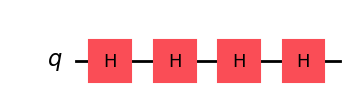

In [ ]:
qc = QuantumCircuit(1)

for i in range(4):
  qc.h(0)

qc.draw('mpl')

Aplicar compuertas **en paralelo** consiste en aplicar compuertas a distintos qubits (o conjuntos de qubits) en un mismo instante de tiempo. Para expresarlo matemáticamente, utilizamos el producto tensorial: si aplicamos las compuertas $U_1$, $U_2$ y $U_3$ a los qubits de un sistema $|\Psi\rangle$ de 3 qubits, el resultado será $(U_1\otimes U_2\otimes U_3)|\Psi\rangle$.

El siguiente código aplica en paralelo cinco compuertas de Hadamard:

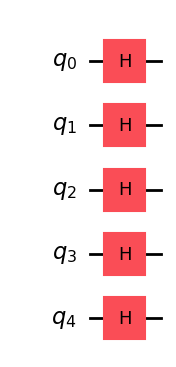

In [ ]:
qubit_num = 5
qc = QuantumCircuit(qubit_num)

for i in range(qubit_num):
  qc.h(i)

qc.draw('mpl')

Supongamos que tenemos un circuito con dos qubits en el estado $|q_1q_2\rangle$ y queremos aplicar una compuerta cuántica solo al primer qubit, dejando intacto el segundo. Esta acción es equivalente a aplicar en paralelo dicha compuerta $U$ al primer qubit y la *compuerta identidad* ($I|q\rangle=|q\rangle$) al segundo. Podemos expresar la operación sobre el estado del sistema como $(U\otimes I )|q_1q_2\rangle=(U|q_1\rangle)|q_2\rangle$. Este concepto puede extenderse a cualquier cantidad de qubits.



### Transformada de Hadamard

Consideremos qué obtenemos al aplicar en paralelo $n$ compuertas de Hadamard ($H$) a $n$ qubits en el estado $|0\rangle$ (el código anterior diagrama esta situación para $n=5$).

Podemos expresar al sistema de qubits antes de aplicar las compuertas como $|0\rangle^{\otimes n}$, lo que equivale a hacer el producto tensorial entre $n$ estados $|0\rangle$. De la misma manera, aplicar $n$ compuertas $H$ en paralelo puede escribirse como $H^{\otimes n}$. El resultado de la operación será la superposición equiprobable de los $2^n$ estados posibles:

\begin{equation}
H^{\otimes n}|0\rangle^{\otimes n}=\frac{1}{\sqrt{2^n}}\sum_
{x=0}^{2^n-1}|x\rangle
\end{equation}

En esta expresión, $x$ representa un string binario de longitud $n$. Por ejemplo, para $x=8$, $x=9$ y $x=10$ tenemos los strings $1000$, $1001$ y $1010$ respectivamente (para $n=4$ dígitos de largo). Otra notación muy utilizada para representar strings binarios es $x\in\{0,1\}^n$: se lee como "el conjunto de strings de largo $n$ en el que cada caracter es $0$ ó $1$".

La expresión anterior se conoce como **transformada de Hadamard** (o Walsh-Hadamard) y aparece en muchos algoritmos cuánticos.

**Ejemplo:** si aplicamos dos compuertas de Hadamard en paralelo al estado $|00\rangle$, podemos obtener el resultado de dicha operación con la expresión de la transformada de Hadamard. En este caso, $n=2$; por lo tanto:

\begin{equation}
(H\otimes H)|00\rangle=\frac{1}{\sqrt{2^2}}\sum_
{x=0}^{2^2-1}|x\rangle=\frac{1}{2}\sum_
{x=0}^{3}|x\rangle=\frac{1}{2}(|0\rangle+|1\rangle+|2\rangle+|3\rangle)=\frac{|00\rangle+|01\rangle+|10\rangle+|11\rangle}{2}
\end{equation}

Análogamente, para $n=3$ tenemos:

\begin{align}
H^{\otimes 3}|000\rangle=\frac{1}{\sqrt8}\sum_
{x=0}^{7}|x\rangle&=\frac{|0\rangle+|1\rangle+|2\rangle+|3\rangle+|4\rangle+|5\rangle+|6\rangle+|7\rangle}{\sqrt8}
\\
&=\frac{|000\rangle+|001\rangle+|010\rangle+|011\rangle+|100\rangle+|101\rangle+|110\rangle+|111\rangle}{\sqrt8}
\end{align}


---

En muchos algoritmos, necesitamos aplicar $n$ compuertas de Hadamard en paralelo a otros estados que no son $|0\rangle^{\otimes n}$. Supongamos que tenemos un estado $|x\rangle$ de $n$ qubits. Aplicarle la transformada de Hadamard a $|x\rangle$ es equivalente a aplicar la compuerta $H$ a cada uno de sus dígitos. El resultado está dado por la siguiente expresión:

\begin{equation}
H^{\otimes n}|x\rangle=\frac{1}{\sqrt{2^n}}\sum_
{y=0}^{2^n-1}(-1)^{\vec{x}\cdot\vec{y}}|y\rangle
\end{equation}

donde $\vec{x}$ e $\vec{y}$ son vectores que contienen las representaciones binarias de $x$ e $y$ (muchas veces se utiliza la notación $\bar{x}$, $\bar{y}$ o directamente $x$, $y$). Por ejemplo, si $x=2$ e $y=3$, entonces $\vec{x}=(1,0)$ e $\vec{y}=(1,1)$, y el producto escalar entre los vectores será $\vec{x}\cdot\vec{y}=1\cdot1+1\cdot0=1$. Es importante tener en cuenta que $\vec{x}\cdot\vec{y}$ representa una expresión booleana de un dígito, por lo que si el resultado del producto escalar es $2$, escribiremos $0$ (es una operación módulo 2).

**Ejemplo:** resolvamos la transformada de Walsh-Hadamard para la entrada de tres qubits $|x\rangle=|5\rangle=|101\rangle$.

\begin{equation}
H^{\otimes 3}|5\rangle=H^{\otimes 3}|101\rangle=\frac{1}{\sqrt{8}}\sum_
{y=0}^{7}(-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\vec{y}}|y\rangle
\end{equation}

Expandiendo la suma, tenemos:

\begin{align}
H^{\otimes 3}|5\rangle
= \frac{1}{\sqrt{8}} \Big[
(-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}} |0\rangle
+ (-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 0 \\ 0 \\ 1 \end{pmatrix}} |1\rangle & \nonumber \\
+ (-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 0 \\ 1 \\ 0 \end{pmatrix}} |2\rangle
+ (-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 0 \\ 1 \\ 1 \end{pmatrix}} |3\rangle & \nonumber \\
+ (-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix}} |4\rangle
+ (-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 1 \\ 0 \\ 1 \end{pmatrix}} |5\rangle & \nonumber \\
+ (-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 1 \\ 1 \\ 0 \end{pmatrix}} |6\rangle
+ (-1)^{\begin{pmatrix} 1 & 0 & 1 \end{pmatrix}\cdot\begin{pmatrix} 1 \\ 1 \\ 1 \end{pmatrix}} |7\rangle &
\Big]
\end{align}

Finalmente, resolviendo todos los productos:

\begin{equation}
H^{\otimes 3}|5\rangle
=\frac{1}{\sqrt8}(|000\rangle-|001\rangle+|010\rangle-|011\rangle-|100\rangle+|101\rangle-|110\rangle+|111\rangle)
\end{equation}